# Week 15: ChatGPT and Large Language Models


## Week 15 Meetings

- **Lecture 25:** ChatGPT / LLMs
- **Thanksgiving:** No class


# Lecture 25: ChatGPT / LLMs

Modern conversational language models combine large-scale pretraining with instruction tuning and preference optimization. A small prompt-and-response environment makes supervised fine-tuning, reward modeling, reference policies, KL penalties, and policy optimization visible without requiring a production-scale LLM.


## Imports and Device

The notebook uses PyTorch for all models. The RLHF section uses a tiny discrete response task so the whole pipeline is visible. The vision section uses `torchvision` datasets, transforms, and pretrained models.

In [1]:
# Core Python utilities
from pathlib import Path
from copy import deepcopy
import math
import random
import shutil
import tarfile
import time
import urllib.request

# Numerical and plotting tools
import numpy as np
import matplotlib.pyplot as plt

# PyTorch and torchvision tools
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import datasets, models
from torchvision.transforms import v2 as transforms

# Reporting tools
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Reproducibility
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Device selection
if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

pin_memory = device.type == "cuda"
print(f"Using device: {device}")


Using device: cuda


## Plotting and Evaluation Helpers

These helpers appear near the top because both the RLHF and ViT sections use learning curves and classification metrics.

In [2]:
# Plot training curves stored in a shared history format
def plot_histories(histories, metric_name="validation_accuracy"):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    for name, history in histories.items():
        epochs = range(1, len(history["training_loss"]) + 1)
        plt.plot(epochs, history["training_loss"], label=name)
    plt.xlabel("Epoch")
    plt.ylabel("Training Loss")
    plt.title("Training Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    for name, history in histories.items():
        epochs = range(1, len(history[metric_name]) + 1)
        best_value = max(history[metric_name])
        plt.plot(epochs, history[metric_name], label=f"{name} ({best_value:.3f})")
    plt.xlabel("Epoch")
    plt.ylabel(metric_name.replace("_", " ").title())
    plt.title(metric_name.replace("_", " ").title())
    plt.legend()

    plt.tight_layout()
    plt.show()


# Compute multiclass accuracy from logits and labels
def accuracy_from_logits(logits, labels):
    predictions = logits.argmax(dim=1)
    return (predictions == labels).float().mean().item()


# Part 1: Reinforcement Learning from Human Feedback

Supervised learning teaches a model to imitate examples. For a prompt $x$ and target response $y$, supervised fine-tuning minimizes cross-entropy:

$$\mathcal{L}_{\text{SFT}}(\theta) = -\log \pi_\theta(y \mid x).$$

This is powerful, but it does not directly tell the model which of two plausible responses people prefer. RLHF adds a preference-learning stage.

A common pipeline is:

1. Start with a pretrained or supervised fine-tuned policy $\pi_{\text{ref}}(y \mid x)$.
2. Collect comparisons such as response $y^+$ preferred over response $y^-$ for the same prompt $x$.
3. Train a reward model $r_\phi(x,y)$ that assigns higher scores to preferred responses.
4. Optimize a policy $\pi_\theta$ to receive high reward while staying close to the reference policy.

The usual preference model is Bradley-Terry:

$$P(y^+ \succ y^- \mid x) = \sigma(r_\phi(x,y^+) - r_\phi(x,y^-)).$$

The reward model loss is binary cross-entropy on pairwise comparisons:

$$\mathcal{L}_{\text{reward}}(\phi) = -\log \sigma(r_\phi(x,y^+) - r_\phi(x,y^-)).$$

## A Tiny Preference Dataset

The toy task uses short prompts and a fixed set of possible responses. The response preferences are synthetic, but the training structure matches the real RLHF pipeline:

- a prompt is encoded as an ID,
- a response is encoded as an ID,
- a preference pair says which response is better for a prompt.

This keeps the mechanics visible without needing a large language model.

In [3]:
# Tiny prompt and response vocabulary for the RLHF demonstration
prompts = [
    "Write a helpful answer",
    "Write a concise answer",
    "Write a safe answer",
    "Write an encouraging answer",
    "Write a factual answer",
]

responses = [
    "direct helpful answer",
    "short answer",
    "refuses unsafe request",
    "warm encouraging answer",
    "careful factual answer",
    "vague generic answer",
    "overconfident unsupported answer",
    "needlessly long answer",
]

prompt_to_id = {prompt: index for index, prompt in enumerate(prompts)}
response_to_id = {response: index for index, response in enumerate(responses)}

# Ground-truth preference scores create synthetic pairwise labels
preference_score_table = torch.tensor([
    [4.0, 2.0, 1.0, 3.0, 3.0, 0.5, -1.0, 0.0],
    [2.0, 4.0, 1.0, 2.0, 2.0, 0.0, -1.0, 1.0],
    [1.0, 1.0, 5.0, 2.0, 3.0, 0.0, -2.0, -1.0],
    [3.0, 1.0, 1.0, 5.0, 2.0, 0.5, -1.0, 0.0],
    [2.0, 1.0, 2.0, 2.0, 5.0, 0.5, -2.0, -0.5],
])

print(f"Number of prompts: {len(prompts)}")
print(f"Number of candidate responses: {len(responses)}")


Number of prompts: 5
Number of candidate responses: 8


In [4]:
# Pairwise preference dataset sampled from the synthetic score table
class PreferencePairDataset(Dataset):
    def __init__(self, score_table, number_of_pairs=4000, seed=0):
        generator = torch.Generator().manual_seed(seed)
        pairs = []

        for _ in range(number_of_pairs):
            prompt_id = torch.randint(0, score_table.shape[0], (1,), generator=generator).item()
            first_response = torch.randint(0, score_table.shape[1], (1,), generator=generator).item()
            second_response = torch.randint(0, score_table.shape[1], (1,), generator=generator).item()

            while second_response == first_response:
                second_response = torch.randint(0, score_table.shape[1], (1,), generator=generator).item()

            first_score = score_table[prompt_id, first_response]
            second_score = score_table[prompt_id, second_response]

            if first_score >= second_score:
                chosen_response = first_response
                rejected_response = second_response
            else:
                chosen_response = second_response
                rejected_response = first_response

            pairs.append((prompt_id, chosen_response, rejected_response))

        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        prompt_id, chosen_response, rejected_response = self.pairs[index]
        return (
            torch.tensor(prompt_id, dtype=torch.long),
            torch.tensor(chosen_response, dtype=torch.long),
            torch.tensor(rejected_response, dtype=torch.long),
        )


preference_dataset = PreferencePairDataset(preference_score_table, number_of_pairs=4000, seed=SEED)
train_size = int(0.8 * len(preference_dataset))
val_size = len(preference_dataset) - train_size
preference_train_dataset, preference_val_dataset = random_split(
    preference_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

preference_train_loader = DataLoader(
    preference_train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=pin_memory,
)
preference_val_loader = DataLoader(
    preference_val_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    pin_memory=pin_memory,
)

print(f"Preference train pairs: {len(preference_train_dataset)}")
print(f"Preference validation pairs: {len(preference_val_dataset)}")


Preference train pairs: 3200
Preference validation pairs: 800


## Reward Model

The reward model maps a prompt-response pair to one scalar:

$$r_\phi(x,y) \in \mathbb{R}.$$

Only reward differences matter for pairwise training. If the chosen response should beat the rejected response, the model should make

$$r_\phi(x,y^+) - r_\phi(x,y^-)$$

large and positive.

In [5]:
# Reward model with prompt and response embeddings
class TinyRewardModel(nn.Module):
    def __init__(self, number_of_prompts, number_of_responses, embedding_dim=32, hidden_dim=64):
        super().__init__()
        self.prompt_embedding = nn.Embedding(number_of_prompts, embedding_dim)
        self.response_embedding = nn.Embedding(number_of_responses, embedding_dim)
        self.scorer = nn.Sequential(
            nn.Linear(2 * embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, prompt_ids, response_ids):
        prompt_vectors = self.prompt_embedding(prompt_ids)
        response_vectors = self.response_embedding(response_ids)
        pair_vectors = torch.cat([prompt_vectors, response_vectors], dim=1)
        return self.scorer(pair_vectors).squeeze(1)


def reward_preference_loss(chosen_scores, rejected_scores):
    return -F.logsigmoid(chosen_scores - rejected_scores).mean()


reward_model | Epoch 001 | Train Loss: 0.4910 | Val Loss: 0.3659 | Val Pref Acc: 0.8988
reward_model | Epoch 002 | Train Loss: 0.2904 | Val Loss: 0.2459 | Val Pref Acc: 0.9050
reward_model | Epoch 003 | Train Loss: 0.2053 | Val Loss: 0.1838 | Val Pref Acc: 0.9425
reward_model | Epoch 004 | Train Loss: 0.1579 | Val Loss: 0.1447 | Val Pref Acc: 0.9537
reward_model | Epoch 005 | Train Loss: 0.1263 | Val Loss: 0.1212 | Val Pref Acc: 0.9587
reward_model | Epoch 006 | Train Loss: 0.1048 | Val Loss: 0.1024 | Val Pref Acc: 0.9625
reward_model | Epoch 007 | Train Loss: 0.0910 | Val Loss: 0.0909 | Val Pref Acc: 0.9625
reward_model | Epoch 008 | Train Loss: 0.0815 | Val Loss: 0.0818 | Val Pref Acc: 0.9712
reward_model | Epoch 009 | Train Loss: 0.0742 | Val Loss: 0.0757 | Val Pref Acc: 0.9675
reward_model | Epoch 010 | Train Loss: 0.0691 | Val Loss: 0.0722 | Val Pref Acc: 0.9712
reward_model | Epoch 011 | Train Loss: 0.0667 | Val Loss: 0.0699 | Val Pref Acc: 0.9625
reward_model | Epoch 012 | Train

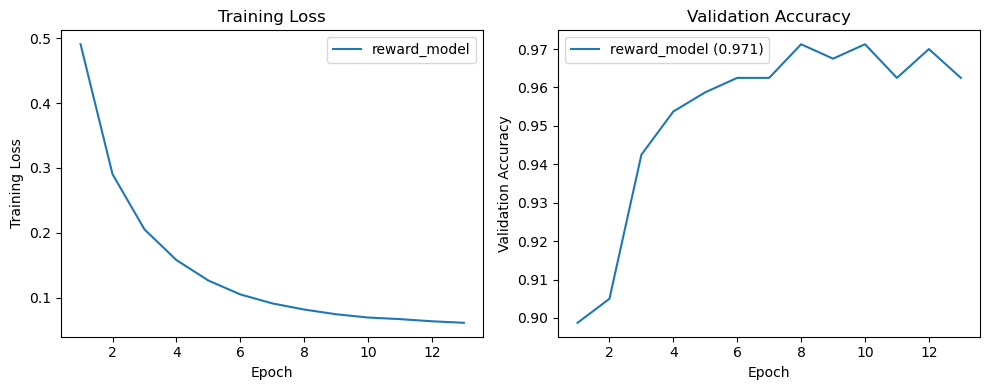

In [6]:
# Train the reward model with early stopping on validation preference accuracy
def train_reward_model(model, train_loader, val_loader, max_epochs=50, patience=5, lr=1e-3):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    history = {"training_loss": [], "validation_loss": [], "validation_accuracy": []}

    best_state = None
    best_val_accuracy = 0.0
    epochs_without_improvement = 0

    for epoch_index in range(max_epochs):
        model.train()
        total_training_loss = 0.0

        for prompt_ids, chosen_ids, rejected_ids in train_loader:
            prompt_ids = prompt_ids.to(device, non_blocking=True)
            chosen_ids = chosen_ids.to(device, non_blocking=True)
            rejected_ids = rejected_ids.to(device, non_blocking=True)

            chosen_scores = model(prompt_ids, chosen_ids)
            rejected_scores = model(prompt_ids, rejected_ids)
            loss = reward_preference_loss(chosen_scores, rejected_scores)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            total_training_loss += loss.item() * prompt_ids.size(0)

        model.eval()
        total_validation_loss = 0.0
        total_correct = 0
        total_examples = 0

        with torch.no_grad():
            for prompt_ids, chosen_ids, rejected_ids in val_loader:
                prompt_ids = prompt_ids.to(device, non_blocking=True)
                chosen_ids = chosen_ids.to(device, non_blocking=True)
                rejected_ids = rejected_ids.to(device, non_blocking=True)

                chosen_scores = model(prompt_ids, chosen_ids)
                rejected_scores = model(prompt_ids, rejected_ids)
                loss = reward_preference_loss(chosen_scores, rejected_scores)

                total_validation_loss += loss.item() * prompt_ids.size(0)
                total_correct += (chosen_scores > rejected_scores).sum().item()
                total_examples += prompt_ids.size(0)

        training_loss = total_training_loss / len(train_loader.dataset)
        validation_loss = total_validation_loss / len(val_loader.dataset)
        validation_accuracy = total_correct / total_examples

        history["training_loss"].append(training_loss)
        history["validation_loss"].append(validation_loss)
        history["validation_accuracy"].append(validation_accuracy)

        print(
            f"reward_model | Epoch {epoch_index + 1:03d} | "
            f"Train Loss: {training_loss:.4f} | Val Loss: {validation_loss:.4f} | "
            f"Val Pref Acc: {validation_accuracy:.4f}"
        )

        if validation_accuracy > best_val_accuracy:
            best_val_accuracy = validation_accuracy
            best_state = deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping reward_model at epoch {epoch_index + 1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history


reward_model = TinyRewardModel(
    number_of_prompts=len(prompts),
    number_of_responses=len(responses),
)
reward_model, reward_history = train_reward_model(
    reward_model,
    preference_train_loader,
    preference_val_loader,
    max_epochs=50,
    patience=5,
    lr=1e-3,
)
plot_histories({"reward_model": reward_history})


## Reference Policy and KL Penalty

RLHF does not usually optimize reward alone. If the policy chases the reward model too aggressively, it may exploit reward-model mistakes. A common objective adds a penalty for moving too far from a reference policy:

$$J(\theta) = \mathbb{E}_{y \sim \pi_\theta(\cdot \mid x)}\left[r_\phi(x,y) - \beta \log \frac{\pi_\theta(y \mid x)}{\pi_{\text{ref}}(y \mid x)}\right].$$

The second term is a sampled version of a KL penalty. The coefficient $\beta$ controls how conservative the update is.

The toy policy below directly learns a categorical distribution over possible responses for each prompt.

In [7]:
# Tiny policy that maps a prompt ID to response logits
class TinyResponsePolicy(nn.Module):
    def __init__(self, number_of_prompts, number_of_responses, embedding_dim=32):
        super().__init__()
        self.prompt_embedding = nn.Embedding(number_of_prompts, embedding_dim)
        self.policy_head = nn.Linear(embedding_dim, number_of_responses)

    def forward(self, prompt_ids):
        prompt_vectors = self.prompt_embedding(prompt_ids)
        return self.policy_head(prompt_vectors)

    def log_probabilities(self, prompt_ids):
        logits = self(prompt_ids)
        return logits.log_softmax(dim=1)


# Supervised targets choose the highest-scoring synthetic response for each prompt
sft_prompt_ids = torch.arange(len(prompts), dtype=torch.long)
sft_target_response_ids = preference_score_table.argmax(dim=1).long()
sft_dataset = torch.utils.data.TensorDataset(sft_prompt_ids, sft_target_response_ids)
sft_loader = DataLoader(sft_dataset, batch_size=len(sft_dataset), shuffle=True)


In [8]:
# Supervised fine-tuning creates the reference policy used by RLHF
def train_reference_policy(model, train_loader, max_epochs=100, lr=1e-2):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_function = nn.CrossEntropyLoss()

    for epoch_index in range(max_epochs):
        model.train()
        for prompt_ids, target_response_ids in train_loader:
            prompt_ids = prompt_ids.to(device)
            target_response_ids = target_response_ids.to(device)

            logits = model(prompt_ids)
            loss = loss_function(logits, target_response_ids)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

    return model


reference_policy = TinyResponsePolicy(len(prompts), len(responses))
reference_policy = train_reference_policy(reference_policy, sft_loader, max_epochs=100, lr=1e-2)
rlhf_policy = deepcopy(reference_policy)

for parameter in reference_policy.parameters():
    parameter.requires_grad = False
reference_policy.eval()


TinyResponsePolicy(
  (prompt_embedding): Embedding(5, 32)
  (policy_head): Linear(in_features=32, out_features=8, bias=True)
)

In [9]:
# Display the most likely response from a policy for each prompt
def show_policy_choices(policy, title):
    policy.eval()
    prompt_ids = torch.arange(len(prompts), dtype=torch.long, device=device)

    with torch.no_grad():
        probabilities = policy(prompt_ids).softmax(dim=1).cpu()

    print(title)
    for prompt_index, prompt in enumerate(prompts):
        response_index = probabilities[prompt_index].argmax().item()
        probability = probabilities[prompt_index, response_index].item()
        print(f"{prompt:<30} -> {responses[response_index]:<32} p={probability:.3f}")


show_policy_choices(reference_policy, "Reference policy choices")


Reference policy choices
Write a helpful answer         -> direct helpful answer            p=0.998
Write a concise answer         -> short answer                     p=0.998
Write a safe answer            -> refuses unsafe request           p=0.998
Write an encouraging answer    -> warm encouraging answer          p=0.999
Write a factual answer         -> careful factual answer           p=0.998


In [10]:
# KL-regularized policy optimization using sampled responses
prompt_sampling_ids = torch.arange(len(prompts), dtype=torch.long, device=device)
policy_optimizer = torch.optim.AdamW(rlhf_policy.parameters(), lr=5e-3, weight_decay=1e-4)
kl_beta = 0.15
number_of_policy_steps = 200
rlhf_history = {"training_loss": [], "mean_reward": [], "mean_kl_penalty": []}

reward_model.eval()
reference_policy.eval()
rlhf_policy.train()

for step_index in range(number_of_policy_steps):
    logits = rlhf_policy(prompt_sampling_ids)
    distribution = torch.distributions.Categorical(logits=logits)
    sampled_response_ids = distribution.sample()
    sampled_log_probs = distribution.log_prob(sampled_response_ids)

    with torch.no_grad():
        reference_log_probs = reference_policy.log_probabilities(prompt_sampling_ids)
        sampled_reference_log_probs = reference_log_probs.gather(1, sampled_response_ids[:, None]).squeeze(1)
        rewards = reward_model(prompt_sampling_ids, sampled_response_ids)

    kl_sample = sampled_log_probs - sampled_reference_log_probs
    objective = rewards - kl_beta * kl_sample
    loss = -(sampled_log_probs * objective.detach()).mean()

    policy_optimizer.zero_grad(set_to_none=True)
    loss.backward()
    policy_optimizer.step()

    rlhf_history["training_loss"].append(loss.item())
    rlhf_history["mean_reward"].append(rewards.mean().item())
    rlhf_history["mean_kl_penalty"].append(kl_sample.mean().item())

    if (step_index + 1) % 25 == 0:
        print(
            f"Step {step_index + 1:03d} | "
            f"Policy Loss: {loss.item():.4f} | "
            f"Mean Reward: {rewards.mean().item():.4f} | "
            f"Mean KL Sample: {kl_sample.mean().item():.4f}"
        )

show_policy_choices(rlhf_policy, "RLHF policy choices")


Step 025 | Policy Loss: 0.0003 | Mean Reward: 5.5310 | Mean KL Sample: 0.0019
Step 050 | Policy Loss: 0.0001 | Mean Reward: 5.5310 | Mean KL Sample: 0.0019
Step 075 | Policy Loss: 0.0001 | Mean Reward: 5.5310 | Mean KL Sample: 0.0019
Step 100 | Policy Loss: 0.0001 | Mean Reward: 5.5310 | Mean KL Sample: 0.0019
Step 125 | Policy Loss: 0.0000 | Mean Reward: 5.5310 | Mean KL Sample: 0.0019
Step 150 | Policy Loss: 0.0000 | Mean Reward: 5.5310 | Mean KL Sample: 0.0019
Step 175 | Policy Loss: 0.0000 | Mean Reward: 5.5310 | Mean KL Sample: 0.0019
Step 200 | Policy Loss: 0.0000 | Mean Reward: 5.5310 | Mean KL Sample: 0.0019
RLHF policy choices
Write a helpful answer         -> direct helpful answer            p=1.000
Write a concise answer         -> short answer                     p=1.000
Write a safe answer            -> refuses unsafe request           p=1.000
Write an encouraging answer    -> warm encouraging answer          p=1.000
Write a factual answer         -> careful factual answer

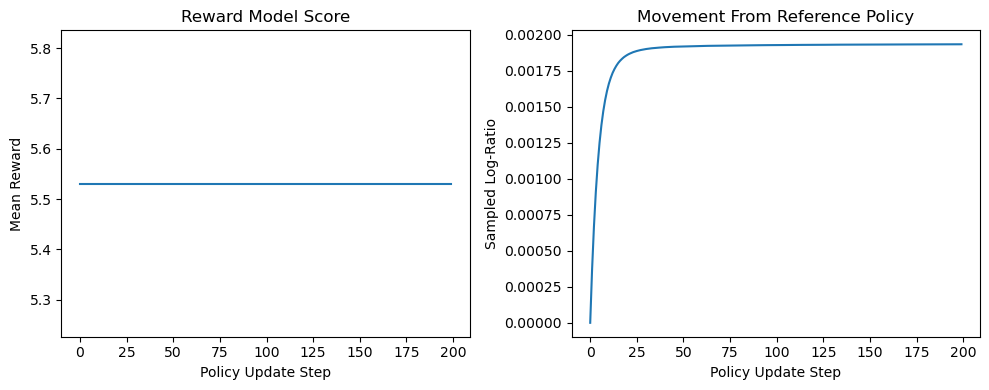

In [11]:
# Plot reward and KL behavior during the toy RLHF update
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(rlhf_history["mean_reward"])
plt.xlabel("Policy Update Step")
plt.ylabel("Mean Reward")
plt.title("Reward Model Score")

plt.subplot(1, 2, 2)
plt.plot(rlhf_history["mean_kl_penalty"])
plt.xlabel("Policy Update Step")
plt.ylabel("Sampled Log-Ratio")
plt.title("Movement From Reference Policy")

plt.tight_layout()
plt.show()


## RLHF Takeaways

RLHF turns subjective or hard-to-write-down preferences into a training signal. The main mathematical pieces are:

- supervised fine-tuning: imitate good examples,
- preference modeling: learn $r_\phi(x,y)$ from comparisons,
- policy optimization: increase reward while controlling distance from a reference policy.

The KL term matters because the reward model is only an approximation. It is usually safer to improve the policy gradually than to let it search freely for reward-model loopholes.

Modern alternatives such as direct preference optimization, or DPO, avoid an explicit reinforcement-learning loop by optimizing a preference objective directly against a reference policy. The conceptual ingredients are still the same: preferences, a reference model, and a penalty for drifting too far from the original behavior.

# Thanksgiving

No class is scheduled.
